In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.manifold import TSNE
import umap

In [2]:
df = pd.read_csv('Chicago_Airbnb_Master_v4.csv')

In [3]:
selected_features = [
    'price', 'accommodates',
    'estimated_annual_revenue', 'occupancy_proxy',
    'shoreline_gravity', 'distance_to_downtown_km',
    'avg_review_length', 'review_scores_rating'
]

In [4]:
X = df[selected_features].copy()
X = X.fillna(X.median())
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [5]:
kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)
df['Final_Integrated_Cluster'] = kmeans.fit_predict(X_scaled)

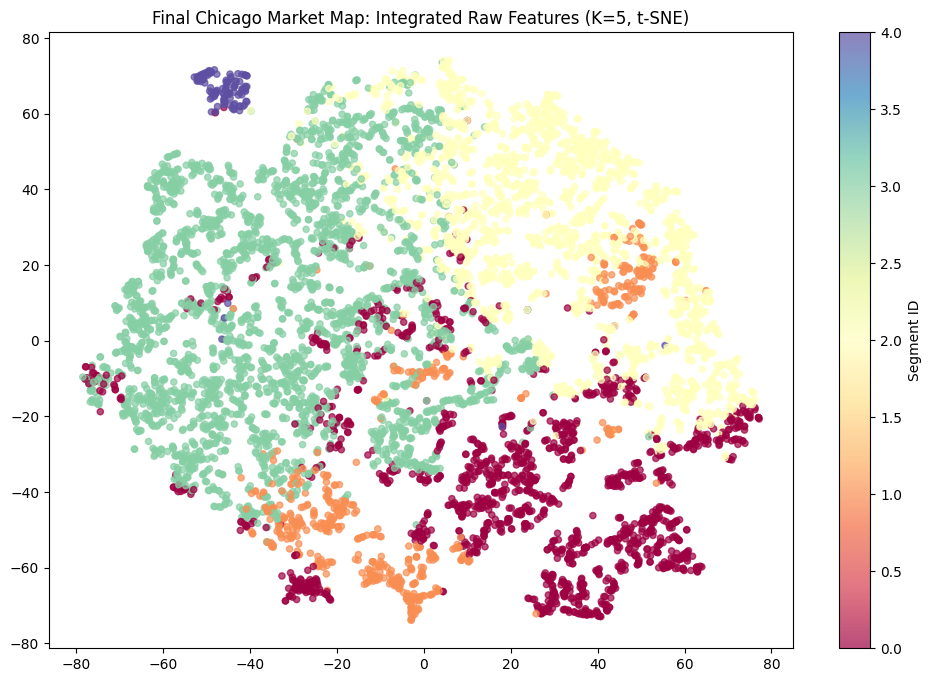

In [7]:
tsne = TSNE(n_components=2, random_state=42, perplexity=30)
embedding = tsne.fit_transform(X_scaled)

plt.figure(figsize=(12, 8))
scatter = plt.scatter(embedding[:, 0], embedding[:, 1],
                      c=df['Final_Integrated_Cluster'],
                      cmap='Spectral', s=20, alpha=0.7)
plt.colorbar(scatter, label='Segment ID')
plt.title('Final Chicago Market Map: Integrated Raw Features (K=5, t-SNE)')
plt.savefig('final_market_map_v4.png')
plt.show()

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


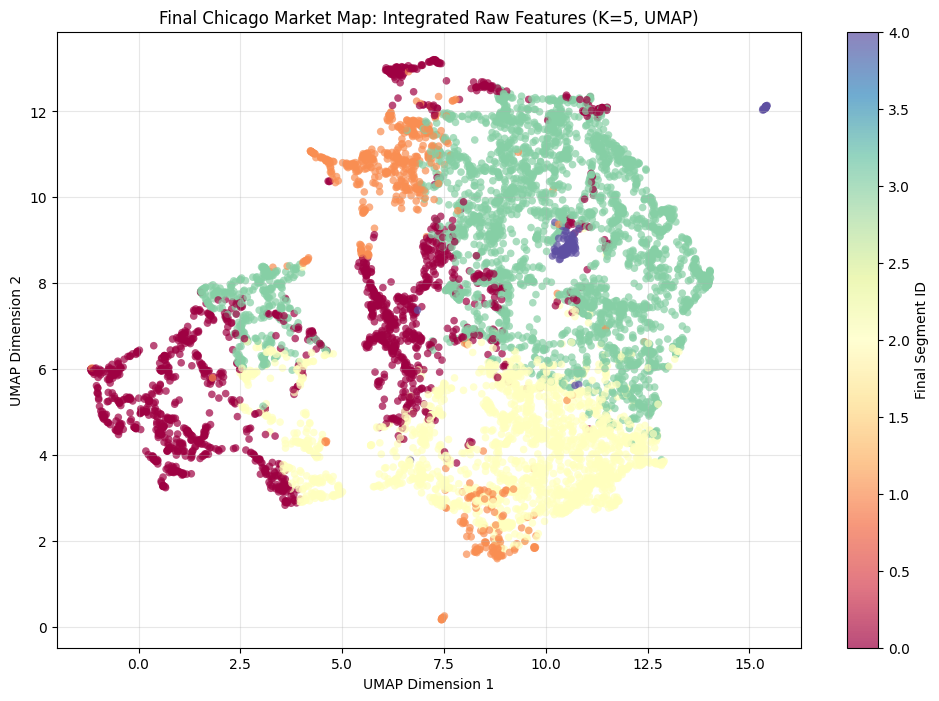

In [9]:
reducer = umap.UMAP(n_neighbors=15, min_dist=0.1, n_components=2, random_state=42)
embedding = reducer.fit_transform(X_scaled)
method_name = "UMAP"

plt.figure(figsize=(12, 8))
scatter = plt.scatter(embedding[:, 0], embedding[:, 1],
                      c=df['Final_Integrated_Cluster'],
                      cmap='Spectral', s=30, alpha=0.7, edgecolors='none')
plt.colorbar(scatter, label='Final Segment ID')
plt.title(f'Final Chicago Market Map: Integrated Raw Features (K=5, {method_name})')
plt.xlabel(f'{method_name} Dimension 1')
plt.ylabel(f'{method_name} Dimension 2')
plt.grid(True, alpha=0.3)
plt.show()

In [12]:
profile = df.groupby('Final_Integrated_Cluster')[selected_features].mean().round(2)
print(profile.sort_values(by='estimated_annual_revenue', ascending=False))

                           price  accommodates  estimated_annual_revenue  \
Final_Integrated_Cluster                                                   
2                         170.84          4.08                  43019.51   
1                         541.04         11.42                  33148.42   
4                         155.91          3.29                  15651.83   
0                         231.93          3.54                  11917.40   
3                         116.60          3.80                   8082.53   

                          occupancy_proxy  shoreline_gravity  \
Final_Integrated_Cluster                                       
2                                    0.72               0.43   
1                                    0.21               0.41   
4                                    0.30               0.49   
0                                    0.17               0.61   
3                                    0.22               0.29   

                  

In [13]:
df.to_csv('Chicago_Airbnb_Final_Analysis_v4.csv', index=False)